In [516]:
import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score


# Metadata

In [517]:
proj_root = os.environ['PYTHONPATH']
proj_root

'C:\\Users\\aseva\\Desktop\\MyEDU\\OTUS\\ML_Adv\\OTUS_ML_Adv_GradProj_SaintSanych_v1'

## preproc params

In [518]:
# здесь мы определяем критерии перегрузки сети
thres_fld = 'n_flows'
thres_factor = 2.5
post_window = 7
drop_inst_ids_list = [246]
horizon = 1
nof_svd_comp_left = 200

# Соберем целевой TS-датасет (пока двумерный)

## сперва посмотрим на данные

In [519]:
flds_selection = [
    'id_time', 
    'n_flows', 'n_packets', 'n_bytes',
    'std_n_dest_ip', 'std_n_dest_ports',
    'tcp_udp_ratio_packets', 'dir_ratio_packets',
    'avg_duration', 'avg_ttl'
]

In [520]:
pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '0.csv'))[flds_selection]

,id_time,n_flows,n_packets,n_bytes,std_n_dest_ip,std_n_dest_ports,tcp_udp_ratio_packets,dir_ratio_packets,avg_duration,avg_ttl
0,0,17967588,2009822494,1937481519695,96.12,63.32,0.76,0.48,20.75,135.95
1,1,17222782,2063503609,2003213170261,95.48,132.03,0.76,0.49,21.05,135.18
2,2,19697341,2458140183,2431213005090,100.91,154.51,0.76,0.47,21.00,137.09
3,3,19702256,2321789135,2273312421852,99.45,139.36,0.76,0.48,20.70,136.28
4,4,17396165,2059123443,2007808467610,86.80,134.48,0.77,0.45,17.70,149.85
...,...,...,...,...,...,...,...,...,...,...
275,275,10660088,1183226129,1156169960010,66.47,59.81,0.74,0.47,22.76,129.99
276,276,11555928,1020931320,974118051467,76.87,176.64,0.74,0.48,22.86,134.34
277,277,11042880,1008125606,964115099922,66.38,88.52,0.74,0.46,21.97,130.42
278,278,9182379,1108790324,1134577908505,57.64,52.35,0.75,0.46,20.80,131.26


## выбор порога нетривиален - с одной стороны, в среднем по всем институтам это должно быть нечастое явление, но для целевого института дать хотя бы 20% случаев - чтобы было на чем обучаться модели! 

In [521]:
top_3 = []

for tmp_thres_factor in [1.5, 2, 2.5, 3, 3.5, 4, 5, 7, 10]:
    overloaded_list = []

    for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

        tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

        tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * tmp_thres_factor

        overloaded_list.append(tmp_df['is_overloaded'].sum())

    top_3.append([tmp_thres_factor] + sorted(overloaded_list)[-3:] + [round(sum(overloaded_list)/280, 2)])

top_3 = np.array(top_3)
top_3

array([[  1.5 , 100.  , 100.  , 103.  ,  33.76],
       [  2.  ,  58.  ,  66.  ,  77.  ,   7.29],
       [  2.5 ,  36.  ,  53.  ,  53.  ,   2.67],
       [  3.  ,  25.  ,  26.  ,  34.  ,   1.49],
       [  3.5 ,  16.  ,  16.  ,  20.  ,   0.91],
       [  4.  ,  15.  ,  16.  ,  16.  ,   0.59],
       [  5.  ,  11.  ,  14.  ,  15.  ,   0.36],
       [  7.  ,   6.  ,  10.  ,  14.  ,   0.22],
       [ 10.  ,   6.  ,   9.  ,  14.  ,   0.16]])

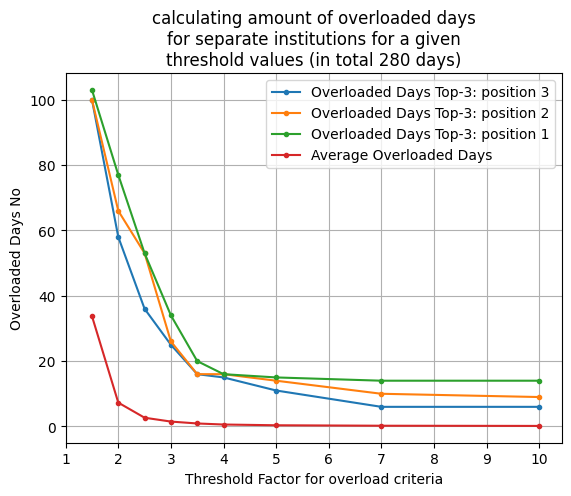

In [522]:
for i in [1,2,3]:
    plt.plot(top_3[:,0], top_3[:,i], label=f'Overloaded Days Top-3: position {4-i}', marker='.')

plt.plot(top_3[:,0], top_3[:,4], label='Average Overloaded Days', marker='.')
plt.title('calculating amount of overloaded days\n' +
          'for separate institutions for a given\n' + 
          'threshold values (in total 280 days)')
plt.xlabel('Threshold Factor for overload criteria')
plt.ylabel('Overloaded Days No')
plt.legend()
plt.xticks(range(1,11))
plt.grid()
plt.show()

In [523]:
for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

    tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

    tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * thres_factor

    if tmp_df['is_overloaded'].sum() > 30:
        print(f"File {csv_file} has {tmp_df['is_overloaded'].sum()} overloaded days")

File 217.csv has 53 overloaded days
File 246.csv has 36 overloaded days
File 264.csv has 53 overloaded days


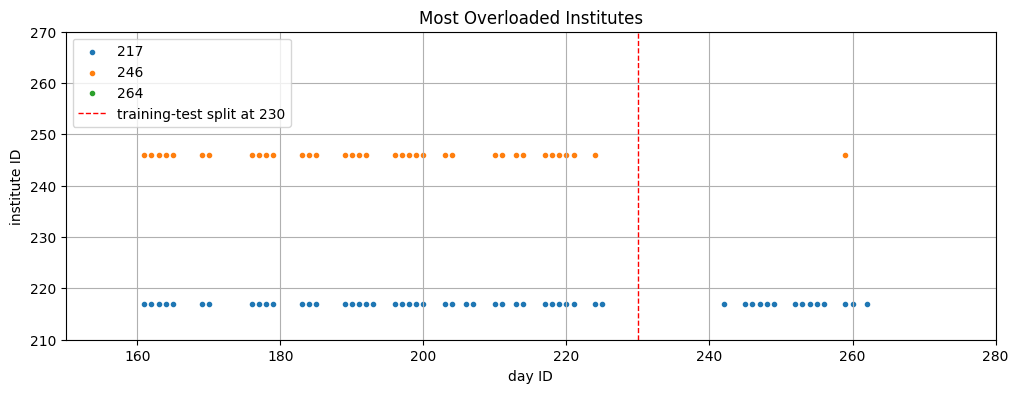

In [524]:
tmp_df_217 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '217.csv'))[flds_selection]
tmp_df_217['is_overloaded'] = tmp_df_217[thres_fld] > tmp_df_217[thres_fld].mean() * thres_factor

tmp_df_246 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '246.csv'))[flds_selection]
tmp_df_246['is_overloaded'] = tmp_df_246[thres_fld] > tmp_df_246[thres_fld].mean() * thres_factor

tmp_df_264 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '264.csv'))[flds_selection]
tmp_df_264['is_overloaded'] = tmp_df_264[thres_fld] > tmp_df_264[thres_fld].mean() * thres_factor

plt.figure(figsize=(12, 4))

plt.scatter(tmp_df_217.id_time, 217*tmp_df_217['is_overloaded'], label='217', marker='.')
plt.scatter(tmp_df_246.id_time, 246*tmp_df_246['is_overloaded'], label='246', marker='.')
plt.scatter(tmp_df_264.id_time, 264*tmp_df_264['is_overloaded'], label='264', marker='.')
plt.axvline(230, color='red', linestyle='--', linewidth=1, label='training-test split at 230')
plt.ylim(210, 270)
plt.xlim(150,280)  #(150, 280)
plt.xlabel('day ID')
plt.ylabel('institute ID')
plt.title('Most Overloaded Institutes')
plt.legend(loc='upper left')
plt.grid()
plt.show()

## итак мы выбрали 217 институт - сохраним разметку по нему

In [525]:
print('\nПри пороговом множителе роста нагрузки по сравнению со средней на уровне', thres_factor,
      'целевая разметка будет:')
pd.DataFrame(
    data=[
        tmp_df_217['is_overloaded'].map(int).value_counts(),
        tmp_df_217['is_overloaded'].map(int).iloc[:230].value_counts(),
        tmp_df_217['is_overloaded'].map(int).iloc[230:].value_counts()
    ],
    index=['All', 'Train', 'Test']
).T


При пороговом множителе роста нагрузки по сравнению со средней на уровне 2.5 целевая разметка будет:


,All,Train,Test
is_overloaded,,,
0,227,191,36
1,53,39,14


In [526]:
tmp_df_217[['id_time','is_overloaded']].map(int).to_csv(
          os.path.join(proj_root, 'preprocessed_datasets', 'inst_217_marked_target.csv'), index=False)

## поехали собирать весь датасет

In [527]:
inst_ids_list = sorted([ int(el.split('.')[0]) 
                         for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) 
                         if el.endswith('.csv') ])

inst_ids_list = [el for el in inst_ids_list if el not in drop_inst_ids_list]


In [528]:
predictors_df = pd.read_csv(os.path.join(proj_root,'preprocessed_datasets','ts_days_df.csv')).drop(columns=['day']) 

for inst_id in inst_ids_list:

    tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', f'{inst_id}.csv'))[flds_selection]
    
    for col in tmp_df.columns:
        if col != 'id_time':
            tmp_df[col] = tmp_df[col].astype(float)
            
    tmp_df.columns = [el + '_' + str(inst_id) for el in tmp_df.columns]
    tmp_df.rename(columns={'id_time' + '_' + str(inst_id): 'id_time'}, inplace=True)

    predictors_df = predictors_df.merge(tmp_df, on='id_time', how='left')

predictors_df.shape

(280, 2541)

**а сколько должно быть?  у нас 283 института, выкинули два id (217 и 246) - каждый институт тащит 9 фич, плюс три общих (таймстемп, день недели и флаг рабочего дня) - итого, все сошлось:**

In [529]:
(9 * (283-2)) + 3

2532

In [530]:
predictors_df

,id_time,day_of_week,is_working_day,n_flows_0,n_packets_0,n_bytes_0,std_n_dest_ip_0,std_n_dest_ports_0,tcp_udp_ratio_packets_0,dir_ratio_packets_0,...,avg_ttl_283,n_flows_284,n_packets_284,n_bytes_284,std_n_dest_ip_284,std_n_dest_ports_284,tcp_udp_ratio_packets_284,dir_ratio_packets_284,avg_duration_284,avg_ttl_284
0,0,0,1,17967588.0,2.009822e+09,1.937482e+12,96.12,63.32,0.76,0.48,...,175.06,22852.0,29771.0,1115958.0,36.05,2.05,0.46,0.47,3.43,207.42
1,1,1,1,17222782.0,2.063504e+09,2.003213e+12,95.48,132.03,0.76,0.49,...,171.19,21166.0,28199.0,1061740.0,33.25,1.78,0.45,0.47,3.57,210.09
2,2,2,1,19697341.0,2.458140e+09,2.431213e+12,100.91,154.51,0.76,0.47,...,168.78,25781.0,34359.0,1294795.0,40.28,2.07,0.47,0.45,3.53,210.00
3,3,3,1,19702256.0,2.321789e+09,2.273312e+12,99.45,139.36,0.76,0.48,...,177.36,25467.0,33715.0,1259480.0,39.80,1.91,0.43,0.45,3.55,208.37
4,4,4,1,17396165.0,2.059123e+09,2.007808e+12,86.80,134.48,0.77,0.45,...,183.41,26797.0,35387.0,1324206.0,39.66,2.04,0.44,0.43,3.60,208.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,2,1,10660088.0,1.183226e+09,1.156170e+12,66.47,59.81,0.74,0.47,...,NaN,2604.0,7289.0,480445.0,6.19,1.40,0.57,0.46,18.43,198.62
276,276,3,1,11555928.0,1.020931e+09,9.741181e+11,76.87,176.64,0.74,0.48,...,NaN,2399.0,6121.0,384697.0,4.77,1.57,0.62,0.45,20.67,211.74
277,277,4,1,11042880.0,1.008126e+09,9.641151e+11,66.38,88.52,0.74,0.46,...,NaN,2651.0,7664.0,503624.0,5.45,1.50,0.59,0.46,23.76,205.29
278,278,5,0,9182379.0,1.108790e+09,1.134578e+12,57.64,52.35,0.75,0.46,...,NaN,2728.0,7849.0,511897.0,6.13,1.65,0.59,0.47,22.67,203.34


### заполняем пропуски средними значениями

In [531]:
print('\nFYI: Number of missing values:', predictors_df.isna().values.sum(), 
      'versus', predictors_df.notna().values.sum(), 'of not missing ones\n')


FYI: Number of missing values: 5157 versus 706323 of not missing ones



In [532]:
predictors_df = predictors_df.fillna(predictors_df.mean(), inplace=True)

print('\nFYI: Number of missing values:', predictors_df.isna().values.sum(), 
      'versus', predictors_df.notna().values.sum(), 'of not missing ones\n')


FYI: Number of missing values: 0 versus 711480 of not missing ones



In [533]:
predictors_df

,id_time,day_of_week,is_working_day,n_flows_0,n_packets_0,n_bytes_0,std_n_dest_ip_0,std_n_dest_ports_0,tcp_udp_ratio_packets_0,dir_ratio_packets_0,...,avg_ttl_283,n_flows_284,n_packets_284,n_bytes_284,std_n_dest_ip_284,std_n_dest_ports_284,tcp_udp_ratio_packets_284,dir_ratio_packets_284,avg_duration_284,avg_ttl_284
0,0,0,1,17967588.0,2.009822e+09,1.937482e+12,96.12,63.32,0.76,0.48,...,175.060000,22852.0,29771.0,1115958.0,36.05,2.05,0.46,0.47,3.43,207.42
1,1,1,1,17222782.0,2.063504e+09,2.003213e+12,95.48,132.03,0.76,0.49,...,171.190000,21166.0,28199.0,1061740.0,33.25,1.78,0.45,0.47,3.57,210.09
2,2,2,1,19697341.0,2.458140e+09,2.431213e+12,100.91,154.51,0.76,0.47,...,168.780000,25781.0,34359.0,1294795.0,40.28,2.07,0.47,0.45,3.53,210.00
3,3,3,1,19702256.0,2.321789e+09,2.273312e+12,99.45,139.36,0.76,0.48,...,177.360000,25467.0,33715.0,1259480.0,39.80,1.91,0.43,0.45,3.55,208.37
4,4,4,1,17396165.0,2.059123e+09,2.007808e+12,86.80,134.48,0.77,0.45,...,183.410000,26797.0,35387.0,1324206.0,39.66,2.04,0.44,0.43,3.60,208.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,2,1,10660088.0,1.183226e+09,1.156170e+12,66.47,59.81,0.74,0.47,...,188.910462,2604.0,7289.0,480445.0,6.19,1.40,0.57,0.46,18.43,198.62
276,276,3,1,11555928.0,1.020931e+09,9.741181e+11,76.87,176.64,0.74,0.48,...,188.910462,2399.0,6121.0,384697.0,4.77,1.57,0.62,0.45,20.67,211.74
277,277,4,1,11042880.0,1.008126e+09,9.641151e+11,66.38,88.52,0.74,0.46,...,188.910462,2651.0,7664.0,503624.0,5.45,1.50,0.59,0.46,23.76,205.29
278,278,5,0,9182379.0,1.108790e+09,1.134578e+12,57.64,52.35,0.75,0.46,...,188.910462,2728.0,7849.0,511897.0,6.13,1.65,0.59,0.47,22.67,203.34


### сохраняем до и после нормализации столбцов

In [534]:
predictors_df.to_csv(os.path.join(proj_root, 'preprocessed_datasets', 'predictors_df.csv'), index=False)

In [535]:
scaler = StandardScaler()

predictors_scaled = predictors_df.copy(deep=True)
predictors_scaled.iloc[:,3:] = scaler.fit_transform(predictors_df.iloc[:,3:])

predictors_scaled.to_csv(os.path.join(proj_root, 'preprocessed_datasets', 'predictors_scaled.csv'), index=False) 

joblib.dump(scaler, os.path.join(proj_root, 'py_obj_saves', 'predictors_scaler.joblib'))

['C:\\Users\\aseva\\Desktop\\MyEDU\\OTUS\\ML_Adv\\OTUS_ML_Adv_GradProj_SaintSanych_v1\\py_obj_saves\\predictors_scaler.joblib']

### выбираем транкирование и сохраняем варианты с уменьшением размерности

In [536]:
pca_object = PCA(n_components=250)
X_pca = pca_object.fit_transform(predictors_df.iloc[:,1:])
X_pca.shape

(280, 250)

In [537]:
svd_object = TruncatedSVD(n_components=250)
X_svd = svd_object.fit_transform(predictors_df.iloc[:,1:])
X_svd.shape

(280, 250)

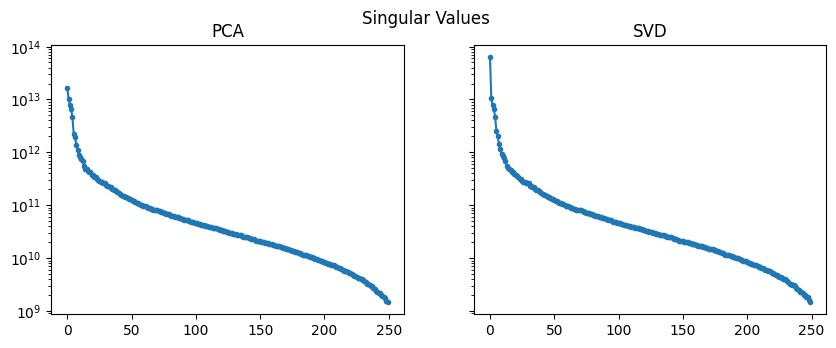

In [538]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

ax1.plot(pca_object.singular_values_, marker='.')
ax1.set_yscale('log')
ax1.set_title('PCA')

ax2.plot(svd_object.singular_values_, marker='.')
ax2.set_yscale('log')
ax2.set_title('SVD')

fig.suptitle('Singular Values')
plt.show()

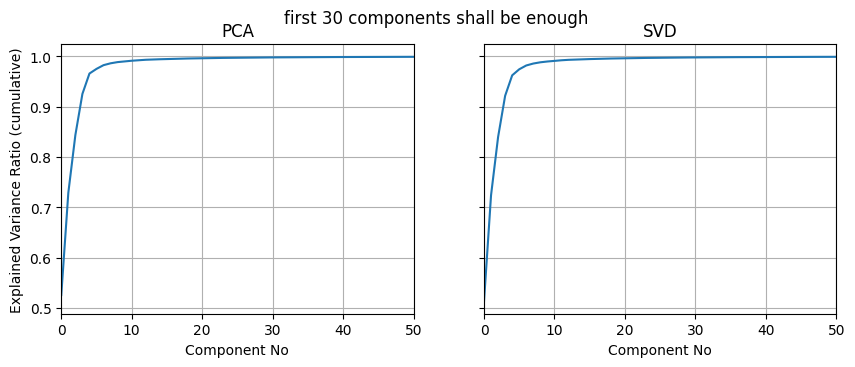

In [539]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

ax1.plot(pd.Series(pca_object.explained_variance_ratio_).cumsum())
ax1.grid()
ax1.set_xlim(0,50)
ax1.set_title('PCA')

ax2.plot(pd.Series(svd_object.explained_variance_ratio_).cumsum())
ax2.grid()
ax2.set_xlim(0,50)
ax2.set_title('SVD')

ax1.set_ylabel('Explained Variance Ratio (cumulative)')
ax1.set_xlabel('Component No')
ax2.set_xlabel('Component No')
fig.suptitle('first 30 components shall be enough')
plt.show()

#### визуально достаточным кажется 20-30 компонент

In [540]:
np.save(os.path.join(proj_root, 'preprocessed_datasets', 'X_pca_30.npy'), X_pca[:, :30])
np.save(os.path.join(proj_root, 'preprocessed_datasets', 'X_svd_30.npy'), X_svd[:, :30])

joblib.dump(pca_object, os.path.join(proj_root, 'py_obj_saves', 'pca_250_object.joblib'))
joblib.dump(svd_object, os.path.join(proj_root, 'py_obj_saves', 'svd_250_object.joblib'))

['C:\\Users\\aseva\\Desktop\\MyEDU\\OTUS\\ML_Adv\\OTUS_ML_Adv_GradProj_SaintSanych_v1\\py_obj_saves\\svd_250_object.joblib']

# dataset 1: window = 7, horizon = 1

In [541]:
X_wd7_h1 = np.stack([
                     np.stack([X_svd[i-post_window:i, :nof_svd_comp_left].flatten()]).copy().flatten() 
                     for i in range(post_window, X_svd.shape[0]-horizon)])

X_wd7_h1.shape

(272, 1400)

In [542]:
Y_wd7_h1 = tmp_df_217['is_overloaded'].map(int).values[post_window + horizon : tmp_df_217.shape[0]]
Y_wd7_h1.shape

(272,)

In [543]:
X_wd7_h1_train = X_wd7_h1[:-50]
X_wd7_h1_test = X_wd7_h1[-50:]

Y_wd7_h1_train = Y_wd7_h1[:-50]
Y_wd7_h1_test = Y_wd7_h1[-50:]

In [544]:
pd.DataFrame(
    index=['Train', 'Test'],
    data=[pd.Series(Y_wd7_h1_train).value_counts(), pd.Series(Y_wd7_h1_test).value_counts()]
    ).T

,Train,Test
0,183,36
1,39,14


## ML-baseline

In [545]:
model = HistGradientBoostingClassifier()

model.fit(X_wd7_h1_train, Y_wd7_h1_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [546]:
pd.DataFrame({'predicted': model.predict(X_wd7_h1_test), 'actual': Y_wd7_h1_test})

,predicted,actual
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
5,1,0
6,0,0
7,0,0
8,0,0
9,0,0


In [547]:
(model.score(X_wd7_h1_test, Y_wd7_h1_test), 
precision_score(Y_wd7_h1_test, model.predict(X_wd7_h1_test), average='macro'), 
recall_score(Y_wd7_h1_test, model.predict(X_wd7_h1_test), average='macro'))

(0.72, 0.625, 0.5654761904761905)